<a href="https://colab.research.google.com/github/JOk3r01001/Pipeline-approach-for-fracture-classification-using-YOLO-and-Keras/blob/main/keras_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive


#Připojení Google Disku do prostředí Colab pro přístup k souborům
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
import numpy as np
import pandas as pd
import shutil
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import matplotlib.pyplot as plt

# Cesty k datům a výstupní složce
BASE_PATH = "/content/drive/MyDrive/BK2.0/FracAtlas2"
PROJECT_OUT = "/content/drive/MyDrive/YOLO_undersample"
IMG_SIZE = (640, 640)
BATCH_SIZE = 8


# Načtení CSV souborů s rozdělenými daty
train_df = pd.read_csv(os.path.join(PROJECT_OUT, 'universal_train_split.csv'))
val_df = pd.read_csv(os.path.join(PROJECT_OUT, 'universal_val_split.csv'))
test_df = pd.read_csv(os.path.join(PROJECT_OUT, 'universal_test_split.csv'))

# Sestavení celé cesty k obrázku podle třídy (Fractured / Non_fractured)
def get_full_path(row):
    folder = 'Fractured' if row['label'] == 1 else 'Non_fractured'
    return os.path.join(BASE_PATH, 'images', folder, row['img_name'])

train_df['filepath'] = train_df.apply(get_full_path, axis=1)
val_df['filepath'] = val_df.apply(get_full_path, axis=1)
test_df['filepath'] = test_df.apply(get_full_path, axis=1)

# Převod číselného labelu na řetězec pro ImageDataGenerator
train_df['label_str'] = train_df['label'].astype(str)
val_df['label_str'] = val_df['label'].astype(str)
test_df['label_str'] = test_df['label'].astype(str)

print(f"Before cleaning:")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Detekce a odstranění poškozených obrázků z dataframů
def check_and_remove_corrupted(df, split_name):
    corrupted_idx = []
    for idx, row in df.iterrows():
        try:
            with Image.open(row['filepath']) as img:
                img.verify()
        except Exception:
            corrupted_idx.append(idx)
            print(f"  Corrupted: {row['img_name']}")
    print(f"{split_name}: {len(corrupted_idx)} corrupted removed")
    return df.drop(corrupted_idx).reset_index(drop=True)

train_df = check_and_remove_corrupted(train_df, 'TRAIN')
val_df = check_and_remove_corrupted(val_df, 'VAL')
test_df = check_and_remove_corrupted(test_df, 'TEST')

print(f"\nAfter cleaning:")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Vytvoření lokální adresářové struktury pro rychlejší načítání dat
LOCAL_KERAS = "/content/keras_data"

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(LOCAL_KERAS, split, 'Fractured'), exist_ok=True)
    os.makedirs(os.path.join(LOCAL_KERAS, split, 'Non_fractured'), exist_ok=True)

# Zkopírování obrázků z Google Drive do lokálního prostředí
def copy_to_local(df, split_name):
    print(f"Copying {split_name}...")
    for idx, row in df.iterrows():
        folder = 'Fractured' if row['label'] == 1 else 'Non_fractured'
        dst = os.path.join(LOCAL_KERAS, split_name, folder, row['img_name'])
        if not os.path.exists(dst):
            shutil.copy(row['filepath'], dst)
    print(f"  Done: {len(df)} images")

copy_to_local(train_df, 'train')
copy_to_local(val_df, 'val')
copy_to_local(test_df, 'test')

print("\nAll data copied locally!")

# Aktualizace cest na lokální prostředí
def get_local_path(row, split):
    folder = 'Fractured' if row['label'] == 1 else 'Non_fractured'
    return os.path.join(LOCAL_KERAS, split, folder, row['img_name'])

train_df['filepath'] = train_df.apply(lambda r: get_local_path(r, 'train'), axis=1)
val_df['filepath'] = val_df.apply(lambda r: get_local_path(r, 'val'), axis=1)
test_df['filepath'] = test_df.apply(lambda r: get_local_path(r, 'test'), axis=1)



# Definice augmentací pro trénovací data
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    horizontal_flip=True,
    rotation_range=15,
    fill_mode='nearest'
)

# Validační + Testovací data -- normalizace
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Vytvoření generátorů dat ze dataframů
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['0', '1'],
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['0', '1'],
    shuffle=False
)

 # Pouzity val_gen
test_gen = val_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['0', '1'],
    shuffle=False
)

print("\nGenerators ready!")
print(f"Train batches: {len(train_gen)}")
print(f"Val batches:   {len(val_gen)}")
print(f"Test batches:  {len(test_gen)}")

Before cleaning:
Train: 1722 | Val: 408 | Test: 409
TRAIN: 0 corrupted removed
VAL: 0 corrupted removed
TEST: 0 corrupted removed

After cleaning:
Train: 1722 | Val: 408 | Test: 409
Copying train...
  Done: 1722 images
Copying val...
  Done: 408 images
Copying test...
  Done: 409 images

All data copied locally!
Found 1722 validated image filenames belonging to 2 classes.
Found 408 validated image filenames belonging to 2 classes.
Found 409 validated image filenames belonging to 2 classes.

Generators ready!
Train batches: 216
Val batches:   51
Test batches:  52


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
from PIL import Image
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Základní konfigurace trénování
PROJECT_OUT = "/content/drive/MyDrive/KerasNET"


# Načtení předtrénovaného backbone EfficientNetB1 bez klasifikační hlavy
backbone = EfficientNetB1(
    include_top=False,
    weights='imagenet',
    input_shape=(640, 640, 3)
)
backbone.trainable = True

# Definice vlastní klasifikační hlavy
inputs = keras.Input(shape=(640, 640, 3))
x = backbone(inputs, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

# Kompilace modelu
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# Definice callback funkcí pro řízení průběhu trénování
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_recall',
        patience=10,
        mode='max',
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(PROJECT_OUT, 'efficientnet_best.keras'),
        monitor='val_recall',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7
    ),
    keras.callbacks.CSVLogger(
        os.path.join(PROJECT_OUT, 'efficientnet_training_log.csv')
    )
]

# Spuštění trénování modelu na trénovaích datech s validací
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks
)

# Vyhodnocení modelu
print("\nTest set evaluation:")
results = model.evaluate(test_gen)
print(f"Accuracy:  {results[1]:.4f}")
print(f"Precision: {results[2]:.4f}")
print(f"Recall:    {results[3]:.4f}")
print(f"AUC:       {results[4]:.4f}")


test_gen.reset()
preds = (model.predict(test_gen) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(
    test_gen.classes,
    preds,
    target_names=['No Fracture', 'Fracture']
))

# Matice záměn pro vizualizaci správných a nesprávných klasifikací
cm = confusion_matrix(test_gen.classes, preds)
print("\nConfusion Matrix:")
print(cm)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 640, 640, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 20, 20, 1280)   │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,941,320 (26.48 MB)

 Trainable params: 6,876,705 (26.23 MB)

 Non-trainable params: 64,615 (252.41 KB)

Epoch 1/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 427s 1s/step - accuracy: 0.6594 - auc: 0.6354 - loss: 0.7575 - precision: 0.4864 - recall: 0.3693 - val_accuracy: 0.8162 - val_auc: 0.8016 - val_loss: 0.5042 - val_precision: 0.4706 - val_recall: 0.4507 - learning_rate: 5.0000e-04
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.7476 - auc: 0.7646 - loss: 0.5949 - precision: 0.6218 - recall: 0.5335 - val_accuracy: 0.8162 - val_auc: 0.8229 - val_loss: 0.4072 - val_precision: 0.4762 - val_recall: 0.5634 - learning_rate: 5.0000e-04
Epoch 3/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.7799 - auc: 0.8257 - loss: 0.4766 - precision: 0.6866 - recall: 0.6106 - val_accuracy: 0.7598 - val_auc: 0.8559 - val_loss: 0.4643 - val_precision: 0.4029 - val_recall: 0.7887 - learning_rate: 5.0000e-04
Epoch 4/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.8095 - auc: 0.8579 - loss: 0.4433 - precision: 0.7715 - recall: 0.6644 - val_accuracy: 0.8824 - val_auc: 0.8964 - val_lo

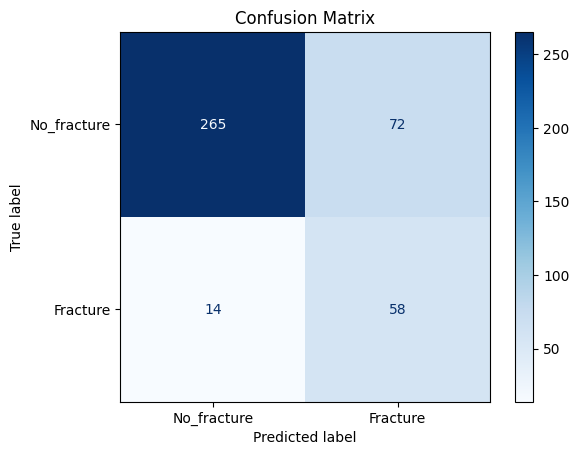

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([[265, 72],
               [14, 58]])


classes = ["No_fracture", "Fracture"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(values_format='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()